In [2]:
from Bio import Phylo
import baltic as bt
from pathlib import Path 
import pylab
import matplotlib.pyplot as plt
import matplotlib as mpl
import requests
from io import StringIO as sio
from matplotlib.lines import Line2D
import re
import inspect

### **Species Tree**


Tree height: 0.002980
Tree length: 0.011120
strictly bifurcating tree

Numbers of objects in tree: 9 (4 nodes and 5 leaves)



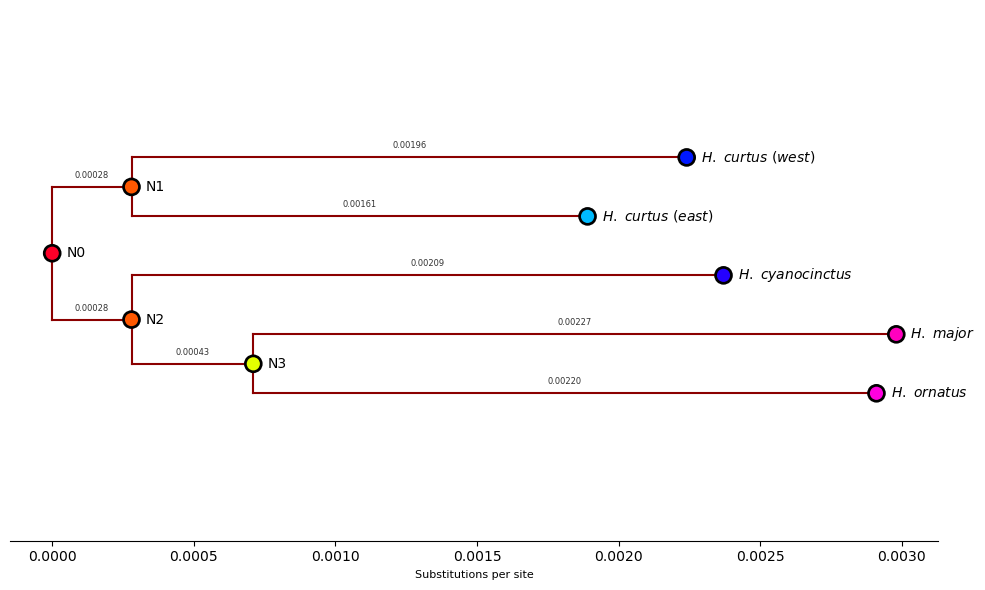

In [158]:
treeFile = Path("/hpcfs/users/a1864358/sanders_lab/phylogenomics/primary_transcripts/OrthoFinder/orthofinder_prot/Species_Tree/SpeciesTree_rooted_node_labels.txt.nhx")


ll = bt.loadNewick(str(treeFile), absoluteTime=False)
ll.treeStats()

# Longest child toward the figure edge: top of an upper clade, bottom of a lower clade.
# Plain sortBranches(longest-first) put hmaj inward because N3 is the lower clade.
def _max_terminal_length(k):
    if k.is_leaf():
        return k.length
    return max(_max_terminal_length(c) for c in k.children)

def sort_longest_outside(tree, node=None, outer_is_first=True):
    if node is None:
        node = tree.root
    if not getattr(node, "children", None):
        return
    node.children.sort(key=_max_terminal_length, reverse=outer_is_first)
    n = len(node.children)
    for i, child in enumerate(node.children):
        if not child.is_node():
            continue
        if n == 1:
            child_outer_first = outer_is_first
        elif i == 0:
            child_outer_first = True
        elif i == n - 1:
            child_outer_first = False
        else:
            child_outer_first = outer_is_first
        sort_longest_outside(tree, child, child_outer_first)
    if node is tree.root:
        tree.drawTree()

sort_longest_outside(ll)

cmap=mpl.cm.gist_rainbow
c_func=lambda k: cmap(k.height/ll.treeHeight)        


fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")

# For ordinary OrthoFinder branch lengths -> height is substitutions/site.
x_attr = lambda k: k.height

# branch length values
for k in ll.Objects:
    branch_length = getattr(k, "length", None)

    if branch_length is None or branch_length <= 0:
        continue

    x_end = x_attr(k)
    x_mid = x_end - branch_length / 2

    ax.text(
        x_mid,
        k.y + 0.12,                 
        f"{branch_length:.5f}",
        ha="center",
        va="bottom",
        fontsize=6,
        color="#333333",
        bbox=dict(
            boxstyle="round,pad=0.12",
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
        ),
        zorder=200,
    )

ll.plotTree(
    ax,
    x_attr=x_attr,
    colour="darkred",
    width=1.5,
    zorder=10,
)

ll.plotPoints(
    ax,
    x_attr=x_attr,
    target=lambda k: k.is_node(),
    size=90,
    colour=c_func,
    zorder=100,
)

# Leaf markers
ll.plotPoints(
    ax,
    x_attr=x_attr,
    target=lambda k: k.is_leaf(),
    size=90,
    colour=c_func,
    zorder=100,
)

species_names = {
    "hmaj": "H. major",
    "hcure": "H. curtus (east)",
    "hcurw": "H. curtus (west)",
    "hcy": "H. cyanocinctus",
    "horn": "H. ornatus",
}

for k in ll.getExternal():
    if k.is_leaf():
        spec = species_names.get(k.name, k.name)
        spec_i = spec.replace(" ", r"\ ")
        ax.text(
            x_attr(k) + 0.00005,
            k.y,
            rf"$\it{{{spec_i}}}$",
            va="center",
            fontsize=10,
        )

for k in ll.getInternal():
    for key, value in k.traits.items():
        if k.is_node():
            ax.text(
                x_attr(k) + 0.00005,
                k.y,
                value,
                va="center",
                fontsize=10,
            )
        

ax.set_ylim(-2, ll.ySpan + 2)
ax.set_yticks([])

for loc in ax.spines:
    ax.spines[loc].set_visible(loc == "bottom")

ax.set_xlabel("Substitutions per site", fontsize=8)

plt.tight_layout()
plt.show()

`orthofinder-tools`
- annotate_orthogroups
- orthofinder_plots